# **Machine Learning on Big Data (CN7030) CRWK 23-24 Term B [60% weighting]**
# **Group ID: [Your Group ID]**
1.   Student 1: Jadyn Vigil, 2579155
2.   Student 2: Name and ID
3.   Student 3: Name and ID

---

If you want to add comments on your group work, please write it here for us:


# **Initiate and Configure Spark**

In [ ]:
!pip3 install pyspark


In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# Initialize SparkSession
spark = SparkSession.builder \
                    .appName("LinearRegressionCoursework") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the compressed file as a text file
df = spark.read.csv("/content/drive/MyDrive/Data Sets/original_cleaned_nyc_taxi_data_2018.csv", inferSchema= True, header = True)

# Display the DataFrame
df.show(20)

# more info #753.7MB
print(df.rdd.getNumPartitions())
print((df.count(), len(df.columns)))
df.columns

+---+-------------+---------+------------------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+-----------------------+
|_c0|trip_distance|rate_code|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|     trip_duration|calculated_total_amount|
+---+-------------+---------+------------------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+------------------+-----------------------+
|  3|        16.97|        1|                 N|           1|       49.5|  0.0|    0.5|      5.61|        5.76|          0.3|       61.67|               231|                138|2018|    3| 29|          3|         13|    

['_c0',
 'trip_distance',
 'rate_code',
 'store_and_fwd_flag',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'imp_surcharge',
 'total_amount',
 'pickup_location_id',
 'dropoff_location_id',
 'year',
 'month',
 'day',
 'day_of_week',
 'hour_of_day',
 'trip_duration',
 'calculated_total_amount']

This dataset includes NYC yellow taxi trips. It contains 8,319,928 individual data points that have been distributed across 6 partitions, and consists of 21 columns. Each partition gets about 125.6MB. These columns consist of payments made, distances, and a variable containing the total amount spent on the taxi ride.

---
# **Task 1 - Data Loading and Preprocessing (15 marks)**
---

In [ ]:
#Identify the student who made a contribution and mention their name in the appropriate section of the code.

## Jadyn Vigil

df.printSchema()


root
 |-- _c0: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- rate_code: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- imp_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- pickup_location_id: integer (nullable = true)
 |-- dropoff_location_id: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- trip_duration: double (nullable = true)
 |-- calculated_total_amount: double (nullable = true)



The schema is checked to make sure there aren't any strings.

In [ ]:
#Check for missing values
from pyspark.sql.functions import col, sum

# Calculate the number of null values in each column
missing_values = [sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]

# Show values missing
values_missing = df.select(missing_values)
values_missing.show()

+---+-------------+---------+------------------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+-------------+-----------------------+
|_c0|trip_distance|rate_code|store_and_fwd_flag|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|pickup_location_id|dropoff_location_id|year|month|day|day_of_week|hour_of_day|trip_duration|calculated_total_amount|
+---+-------------+---------+------------------+------------+-----------+-----+-------+----------+------------+-------------+------------+------------------+-------------------+----+-----+---+-----------+-----------+-------------+-----------------------+
|  0|            0|        0|                 0|           0|          0|    0|      0|         0|           0|            0|           0|                 0|                  0|   0|    0|  0|          0|          0|            0|     

Missing values are checked for each column. The only column with missing values is the calculated_total_amount column.

In [ ]:
# drop columns
final_df = df.drop("_c0", "rate_code", "store_and_fwd_flag","payment_type", "pickup_location_id", "dropoff_location_id", "year", "month", "day", "day_of_week", "hour_of_day", "trip_duration", "calculated_total_amount")
final_df.show(10)

+-------------+-----------+-----+-------+----------+------------+-------------+------------+
|trip_distance|fare_amount|extra|mta_tax|tip_amount|tolls_amount|imp_surcharge|total_amount|
+-------------+-----------+-----+-------+----------+------------+-------------+------------+
|        16.97|       49.5|  0.0|    0.5|      5.61|        5.76|          0.3|       61.67|
|        14.45|       45.5|  0.0|    0.5|     10.41|        5.76|          0.3|       62.47|
|         11.6|       42.0|  0.0|    0.5|     14.57|        5.76|          0.3|       63.13|
|          5.1|       26.5|  1.0|    0.5|      5.65|         0.0|          0.3|       33.95|
|        11.11|       45.5|  1.0|    0.5|     10.61|        5.76|          0.3|       63.67|
|         9.54|       41.0|  1.0|    0.5|      9.71|        5.76|          0.3|       58.27|
|         10.0|       38.5|  1.0|    0.5|      8.05|         0.0|          0.3|       48.35|
|          9.8|       38.5|  1.0|    0.5|      6.94|        5.76|     

I dropped the selected columns because they weren't relevant contributing features to calculating the total amount or to the price prediction task using regression models. The calculated_total_amount column was dropped due to the missing values, the total_amount column will be used as the labeled column.

In [ ]:
# combine features into a single vector column using VectorAssembler
assembler = VectorAssembler(inputCols=["trip_distance", "fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount", "imp_surcharge"],
                            outputCol="features")

# Apply VectorAssembler to final_df to show one input column and one output column
dataset = assembler.transform(final_df)

# Select only the "features" and "total_amount" column to predict
dataset = dataset.select("features", "total_amount")

# Show the first 5 rows of the DataFrame, see all records without truncation
dataset.show(5, truncate=False)

+-----------------------------------+------------+
|features                           |total_amount|
+-----------------------------------+------------+
|[16.97,49.5,0.0,0.5,5.61,5.76,0.3] |61.67       |
|[14.45,45.5,0.0,0.5,10.41,5.76,0.3]|62.47       |
|[11.6,42.0,0.0,0.5,14.57,5.76,0.3] |63.13       |
|[5.1,26.5,1.0,0.5,5.65,0.0,0.3]    |33.95       |
|[11.11,45.5,1.0,0.5,10.61,5.76,0.3]|63.67       |
+-----------------------------------+------------+
only showing top 5 rows



I combined the selected features to contribute to the price prediction into a features column, and am using the total_amount as the labeled column.

In [ ]:
# Normalize the data by scaling
scaler = StandardScaler(inputCol = 'features', outputCol = 'scaledFeatures')

# Fit the scaler to the data and transform the features
scaler_model = scaler.fit(dataset)
data_scaled = scaler_model.transform(dataset)

data_scaled = data_scaled.select('scaledFeatures', 'total_amount')
data_scaled.show(5, truncate = False)

+-----------------------------------------------------------------------------------------------------------------------------------+------------+
|scaledFeatures                                                                                                                     |total_amount|
+-----------------------------------------------------------------------------------------------------------------------------------+------------+
|[2.884850263598151,0.6539783410641749,0.0,6.043060556946095,1.227546659284149,1.5353832540051882,80.12909813820313]                |61.67       |
|[2.456457649321938,0.6011316064327263,0.0,6.043060556946095,2.277853961345453,1.5353832540051882,80.12909813820313]                |62.47       |
|[1.9719660022238394,0.5548907136302089,0.0,6.043060556946095,3.188120289798583,1.5353832540051882,80.12909813820313]               |63.13       |
|[0.8669850527018603,0.35010961693334613,1.766231153223802,6.043060556946095,1.2362992201346599,0.0,80.12909813820313]

The StandardScaler feature was used to normalize the data. It will keep the values around the mean and consider standard deviation. I fit the data which will compute the mean and standard deviation and store scaling parameters. I transformed the data which will scale the features of the data using parameters learned during fitting.

In [ ]:
# split data
train_data, test_data = data_scaled.randomSplit([0.7, 0.3], seed = 21)
train_data.show(5, truncate = False)

+-----------------------------------------------------+------------+
|scaledFeatures                                       |total_amount|
+-----------------------------------------------------+------------+
|(7,[0,1],[0.003399941383144551,0.03302920914465529]) |2.5         |
|(7,[0,1],[0.006799882766289102,0.9644529070239346])  |73.0        |
|(7,[0,1],[0.008499853457861377,0.792701019471727])   |60.0        |
|(7,[0,1],[0.016999706915722754,0.039635050973586355])|3.0         |
|(7,[0,1],[1.6829709846565526,0.9520339243855442])    |72.06       |
+-----------------------------------------------------+------------+
only showing top 5 rows



70% of the data will go to training, and 30% will go to testing.

---
# **Task 2 - Model Selection and Implementation (25 marks)**
---


In [ ]:
##1st student name: Jadyn Vigil
# Apply Linear Regression
lr = LinearRegression(labelCol = 'total_amount', featuresCol = 'scaledFeatures', predictionCol = 'prediction')

# Fit the model to the training data
lr_model = lr.fit(train_data)

# Make prediction on the test data using transform
lr_predictions = lr_model.transform(test_data)

lr_predictions.select('prediction', 'total_amount').show(10, truncate = False)


+------------------+------------+
|prediction        |total_amount|
+------------------+------------+
|45.85694523563021 |45.85       |
|56.46636085573803 |56.46       |
|67.25598305493278 |67.25       |
|65.30587898322983 |65.3        |
|96.98575809650276 |96.98       |
|70.26578657092618 |70.26       |
|73.06577431926492 |73.06       |
|70.26574826090093 |70.26       |
|117.35552549462263|117.35      |
|60.50353141329312 |60.5        |
+------------------+------------+
only showing top 10 rows



When applying linear regression, the labeled column shows what will be predicted, the features are the scaled features, and the prediction column will show the mathematical results. The training data is being fit to learn and calculate beta0 and beta1. The test data is transformed to apply the learning and make predictions.

In [ ]:
#Access the coefficients and intercept of the model

coefficients = lr_model.coefficients
intercept = lr_model.intercept

print(coefficients)
print(intercept)

[-0.00045071394966665753,75.69045601860002,0.5654997929993214,0.0821316680769739,4.571820353421394,3.7507155669407193,0.003801552090787258]
0.007303885437329494


This showed me that the predictor =

total_amount = 0.007303885437329494 + -0.00045071394966665753 (TRIP DISTANCE) + 75.69045601860002 (IMP SURCHARGE) + ..........

This can be used if any further data is entered to predict the total amount.



In [ ]:
##2nd student name:
# add the code here


In [ ]:
##3rd student name:
# add the code here


---
# **Task 3 - Model Parameter Tuning (20 marks)**
---


In [ ]:
##Jadyn Vigil:
# Apply Lasso Regression
lasso = LinearRegression(labelCol = 'total_amount', featuresCol = 'scaledFeatures',
                         predictionCol = 'prediction', elasticNetParam = 1.0, regParam = 0.08) # lambda: tuning
lasso_model = lasso.fit(train_data)
lasso_predictions = lasso_model.transform(test_data)

lasso_predictions.select('prediction', 'total_amount').show(10, truncate = False)


+------------------+------------+
|prediction        |total_amount|
+------------------+------------+
|46.78928132227141 |45.85       |
|57.38318300433788 |56.46       |
|68.15681157639227 |67.25       |
|66.20977026818967 |65.3        |
|97.84170290606579 |96.98       |
|71.16224457007937 |70.26       |
|73.95799619211387 |73.06       |
|71.16224457007937 |70.26       |
|118.18079595636681|117.35      |
|60.9178118407672  |60.5        |
+------------------+------------+
only showing top 10 rows



I originally had the lambda tuning set to 0.15, but the results were not great. Through trial and error I decided to keep lambda tuning set at 0.08.

In [ ]:
# Ridge
ridge = LinearRegression(labelCol = 'total_amount', featuresCol = 'scaledFeatures',
                         predictionCol = 'prediction', elasticNetParam = 0.0, regParam = 0.08)
ridge_model = ridge.fit(train_data)
ridge_predictions = ridge_model.transform(test_data)
ridge_predictions.select('prediction', 'total_amount').show(10, truncate = False)

+------------------+------------+
|prediction        |total_amount|
+------------------+------------+
|45.94203562564247 |45.85       |
|56.56467148205804 |56.46       |
|67.35501001696201 |67.25       |
|65.41490932030548 |65.3        |
|97.03878366800255 |96.98       |
|70.37036888998053 |70.26       |
|73.16549886350602 |73.06       |
|70.37258292372735 |70.26       |
|117.38164578178241|117.35      |
|60.49580037239025 |60.5        |
+------------------+------------+
only showing top 10 rows



I originally had lambda tuning set to 0.15, but the results were not great. Through trial and error I decided to keep lambda tuning set at 0.08.

In [ ]:
##2nd student name:
# add the code here


In [ ]:
##3rd student name:
# add the code here


---
# **Task 4 - Model Evaluation and Accuracy Calculation (20 marks)**
---

In [ ]:
##Jadyn Vigil:

# calculate MSE - Mean Squared Error
evaluator_mse = RegressionEvaluator(labelCol = 'total_amount', predictionCol = 'prediction', metricName = 'mse')
mse1 = evaluator_mse.evaluate(lr_predictions)
mse2 = evaluator_mse.evaluate(lasso_predictions)
mse3 = evaluator_mse.evaluate(ridge_predictions)

# calculate RMSE - Root of MSE
evaluator_rmse = RegressionEvaluator(labelCol = 'total_amount', predictionCol = 'prediction', metricName = 'rmse')
rmse1 = evaluator_rmse.evaluate(lr_predictions)
rmse2 = evaluator_rmse.evaluate(lasso_predictions)
rmse3 = evaluator_rmse.evaluate(ridge_predictions)

# calculate Root squared
evaluator_r2 = RegressionEvaluator(labelCol = 'total_amount', predictionCol = 'prediction', metricName = 'r2')
r2_mse1 = evaluator_r2.evaluate(lr_predictions)
r2_mse2 = evaluator_r2.evaluate(lasso_predictions)
r2_mse3 = evaluator_r2.evaluate(ridge_predictions)


In [ ]:
print('Linear - MSE: ', mse1, ', RMSE: ', rmse1, ', R^2: ', r2_mse1)
print('Lasso - MSE: ', mse2, ', RMSE: ', rmse2, ', R^2: ', r2_mse2)
print('Ridge - MSE: ', mse3, ', RMSE: ', rmse3, ', R^2: ', r2_mse3)

Linear - MSE:  0.0215439025742994 , RMSE:  0.14677841317543736 , R^2:  0.9999985222109227
Lasso - MSE:  0.07552638193691483 , RMSE:  0.2748206359371778 , R^2:  0.9999948193201352
Ridge - MSE:  0.07285183598182052 , RMSE:  0.2699107926367905 , R^2:  0.9999950027787627


I calculated the accuracy using Mean Squared Error, Root of MSE, and Root Squared MSE. The results show that Linear Regression has the best results in terms of MSE, RMSE, and R Squared.

In [ ]:
##2nd student name:
# add the code here


In [ ]:
##3rd student name:
# add the code here


---
# **Task 5 - Results Visualization or Printing (5 marks)**
---

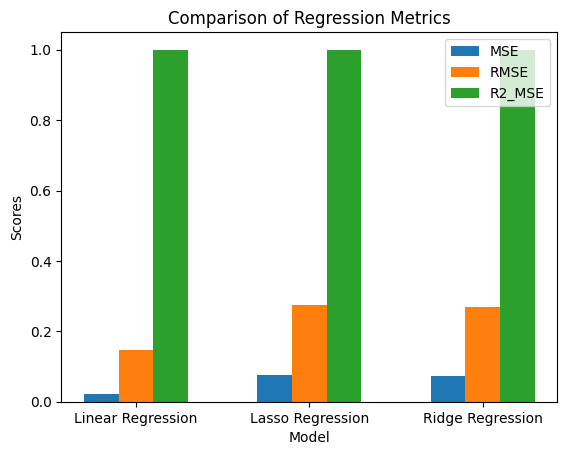

In [ ]:
##Jadyn Vigil:

#plot
import matplotlib.pyplot as plt
import numpy as np

mse = [mse1, mse2, mse3]
rmse = [rmse1, rmse2, rmse3]
r2_mse = [r2_mse1, r2_mse2, r2_mse3]

positions = np.arange(len(mse))
bar_width = 0.2

plt.bar(positions - bar_width, mse, width = bar_width, label = 'MSE')
plt.bar(positions, rmse, width = bar_width, label = 'RMSE')
plt.bar(positions + bar_width, r2_mse, width = bar_width, label = 'R2_MSE')

# adding labels and title
plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Comparison of Regression Metrics')

# adding the legend
plt.legend()
plt.xticks(positions, ['Linear Regression', 'Lasso Regression', 'Ridge Regression'])
plt.show()


This plot shows that R2_MSE scores the highest, while MSE and RMSE score the lowest for linear regression.

In [ ]:
##2nd student name:
# add the code here


In [ ]:
##3rd student name:
# add the code here


---
# **Task 6 - LSEP Considerations (5 marks)**
---

# Jadyn Vigil: Ethics

Using a specified dataset and applying deep learning models to predict an outcome may encounter ethical issues. The ethical implications of the chosen data set, NYC Taxi Data, is that the data does not include cash tips which could lead to a bias in data and not accurately represent the total amount paid. The dataset also may not represent certain areas of New York City due to those areas not being covered by taxis or a limit of the amount of taxis that pick up passengers in that area. There are also privacy concerns in the dataset because passengers may not have given consent to their personal routes being recorded and used by the public. Mitigation strategies that could help improve the ethical implications of using NYC Taxi data is to include sampling data from all areas of NYC, even if that area has very little data. This will allow for sampling to be more representative of the city. Another mitigation strategy that may be useful could be letting passengers know that their route data may be used for educational purposes and allowing them the opportunity to decline.  

# Student 2: **Type the chosen issue**

add contribution here ...

# Student 3: **Type the chosen issue**

add contribution here ...

---

# **Task 7 - Convert ipynb to HTML for Turnitin submission [5 marks]**

---



In [ ]:
# install nbconvert (if facing the conversion error)
!pip3 install nbconvert

In [ ]:
# convert ipynb to html and submit this HTML file
!jupyter nbconvert --to html Your_Group_ID_CRWK_CN7030.ipynb